In [2]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Callable, Dict, Iterable, List, Optional, Tuple
import heapq
import itertools
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [3]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass
     

In [4]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost
     

In [5]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []
    while node is not None:
        path.append(node.state)
        node = node.parent
    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []
    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent
    actions.reverse()
    return actions


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

In [6]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        return state == self.goal

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        legal_actions = []
        
        row, col = state
         
        for action, (dr, dc) in MOVES.items():
            next_state = (row + dr, col + dc)
            
            if self.in_bounds(next_state) and self.is_free(next_state):
                legal_actions.append(action)
        return legal_actions
        

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        row, col = state
        dr, dc = MOVES[action]
        
        return (row + dr, col + dc)

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        return 1



class SearchAlgorithm(ABC):
    """Base class for search algorithms."""
    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        state = node.state
        for action in problem.actions(state):
            next_state = problem.result(state,action)
            
            cost = (
                node.path_cost
                + problem.action_cost(state, action, next_state)
            )
            yield Node(state=next_state, parent=node, action=action, path_cost=cost)

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
            pass

In [7]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path (from Part A)."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

In [8]:
class WeightedGridProblem(GridProblem):
    """A grid problem where entering a cell costs that cell's terrain cost."""

    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
        terrain_costs: List[List[float]],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        terrain_costs:
            2D list, same shape as grid. terrain_costs[r][c] is the cost of
            ENTERING cell (r, c). All values must be >= 1.
        """
        super().__init__(grid, start, goal)
        self.terrain_costs = terrain_costs

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        row, col = next_state
        return self.terrain_costs[row][col]

In [9]:
wtest_grid = [
    [0, 0, 0],
    [0, 0, 0],
    [0, 0, 0],
]

wtest_costs = [
    [1, 7, 1],
    [1, 1, 1],
    [1, 1, 1],
]

wtest_problem = WeightedGridProblem(
    wtest_grid, start=(0, 0), goal=(2, 2), terrain_costs=wtest_costs
)

# Entering the windy cell (0, 1) costs 7.
assert wtest_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 7
# Entering the calm cell (1, 0) costs 1.
assert wtest_problem.action_cost((0, 0), "DOWN", (1, 0)) == 1
# Everything inherited from GridProblem still works.
assert wtest_problem.actions((0, 0)) == ["DOWN", "RIGHT"]
assert wtest_problem.is_goal((2, 2)) is True

print("WeightedGridProblem self-check passed.")
     

WeightedGridProblem self-check passed.


In [10]:
def action_cost(
    self,
    state: Tuple[int, int],
    action: str,
    next_state: Tuple[int, int],
) -> float:
    row, col = next_state
    return self.terrain_costs[row][col]
    

In [11]:
def manhattan_distance(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    r1, c1 = state
    r2, c2 = goal

    return abs(r1 - r2) + abs(c1 - c2)

In [12]:
def euclidean_distance(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    r1, c1 = state
    r2, c2 = goal

    return math.sqrt((r1 - r2) ** 2 + (c1 - c2) ** 2)

In [13]:
def zero_heuristic(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    return 0.0

In [14]:
assert manhattan_distance((0, 0), (2, 2)) == 4
assert manhattan_distance((3, 5), (3, 5)) == 0
assert abs(euclidean_distance((0, 0), (3, 4)) - 5.0) < 1e-9
assert euclidean_distance((1, 1), (1, 1)) == 0
assert zero_heuristic((0, 0), (9, 9)) == 0

# Euclidean never exceeds Manhattan (so Manhattan dominates Euclidean).
for s in [(0, 0), (2, 7), (5, 1)]:
    assert euclidean_distance(s, (9, 9)) <= manhattan_distance(s, (9, 9)) + 1e-9

print("Heuristic self-check passed.")
     

Heuristic self-check passed.


In [15]:
class PriorityQueue:
    """A min-priority queue of (priority, node) pairs built on heapq."""

    def __init__(self):
        self._heap: List[Tuple[float, int, Node]] = []
        self._counter = itertools.count()

    def push(self, priority: float, node: Node) -> None:
        heapq.heappush(self._heap, (priority, next(self._counter), node))

    def pop(self) -> Node:
        priority, count, node = heapq.heappop(self._heap)
        return node

    def __len__(self) -> int:
        return len(self._heap)

    def __bool__(self) -> bool:
        return len(self._heap) > 0

In [16]:

class BestFirstSearch(SearchAlgorithm):
    """Generic best-first search. Subclasses define the evaluation function f(n)."""

    algorithm_name = "BestFirst"

    def __init__(
        self,
        heuristic: Callable[[Tuple[int, int], Tuple[int, int]], float] = zero_heuristic,
    ):
        self.heuristic = heuristic

    def h(self, node: Node, problem: Problem) -> float:
        """Heuristic estimate from this node's state to the goal."""
        return self.heuristic(node.state, problem.goal)

    def evaluation(self, node: Node, problem: Problem) -> float:
        """f(n). Subclasses override this single method."""
        raise NotImplementedError("Subclasses must define evaluation(node, problem)")

    def search(self, problem: Problem) -> SearchResult:

        initial = Node(problem.initial_state())

        frontier = PriorityQueue()
        frontier.push(
            self.evaluation(initial, problem),
            initial
        )

        reached = {initial.state: initial}

        nodes_expanded = 0
        max_frontier_size = 1

        while frontier:

            node = frontier.pop()

            if problem.is_goal(node.state):
                return SearchResult(
                    algorithm=self.algorithm_name,
                    status="success",
                    solution=node,
                    nodes_expanded=nodes_expanded,
                    max_frontier_size=max_frontier_size,
                    reached_count=len(reached)
                )

            nodes_expanded += 1

            for child in self.expand(problem, node):

                s = child.state

                if (
                    s not in reached
                    or child.path_cost < reached[s].path_cost
                ):
                    reached[s] = child

                    frontier.push(
                        self.evaluation(child, problem),
                        child
                    )

            max_frontier_size = max(
                max_frontier_size,
                len(frontier)
            )

        return SearchResult(
            algorithm=self.algorithm_name,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached)
        )

In [17]:
class GreedyBestFirstSearch(BestFirstSearch):
    algorithm_name = "Greedy"

    def evaluation(self, node: Node, problem: Problem) -> float:
        return self.h(node, problem)

In [18]:
class AStarSearch(BestFirstSearch):
    algorithm_name = "A*"

    def evaluation(self, node: Node, problem: Problem) -> float:
       
        return node.path_cost + self.h(node, problem)

In [19]:
class UniformCostSearch(BestFirstSearch):
    """UCS = best-first search with f(n) = g(n). Provided."""

    algorithm_name = "UCS"

    def __init__(self):
        super().__init__(heuristic=zero_heuristic)

    def evaluation(self, node: Node, problem: Problem) -> float:
        return node.path_cost

In [20]:
class WeightedAStarSearch(BestFirstSearch):
    def __init__(self, heuristic, weight: float = 2.0):
        super().__init__(heuristic=heuristic)
        self.weight = weight
        self.algorithm_name = f"Weighted A* (W={weight})"

    def evaluation(self, node: Node, problem: Problem) -> float:
        return node.path_cost + self.weight * self.h(node, problem)

In [21]:
check_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]
check_problem = GridProblem(check_grid, start=(0, 0), goal=(2, 2))

for algo in [
    GreedyBestFirstSearch(manhattan_distance),
    AStarSearch(manhattan_distance),
    WeightedAStarSearch(manhattan_distance, weight=2),
    UniformCostSearch(),
]:
    res = algo.search(check_problem)
     
    print("Algorithm:", res.algorithm)
    print("Status:", res.status)
    print("Solution:", res.solution)
    print("Path:", getattr(res, "path", None))
    print("Cost:", getattr(res, "solution_cost", None))

# A failure case: goal completely walled off.
walled = GridProblem(
    [[0, 1, 0],
     [1, 1, 0],
     [0, 0, 0]],
    start=(0, 0),
    goal=(2, 2),
)
assert AStarSearch(manhattan_distance).search(walled).status == "failure"

print("Algorithm self-check passed.")
     

Algorithm: Greedy
Status: success
Solution: Node(state=(2, 2), parent=Node(state=(1, 2), parent=Node(state=(0, 2), parent=Node(state=(0, 1), parent=Node(state=(0, 0), parent=None, action=None, path_cost=0, depth=0), action='RIGHT', path_cost=1, depth=1), action='RIGHT', path_cost=2, depth=2), action='DOWN', path_cost=3, depth=3), action='DOWN', path_cost=4, depth=4)
Path: [(0, 0), (0, 1), (0, 2), (1, 2), (2, 2)]
Cost: 4
Algorithm: A*
Status: success
Solution: Node(state=(2, 2), parent=Node(state=(1, 2), parent=Node(state=(0, 2), parent=Node(state=(0, 1), parent=Node(state=(0, 0), parent=None, action=None, path_cost=0, depth=0), action='RIGHT', path_cost=1, depth=1), action='RIGHT', path_cost=2, depth=2), action='DOWN', path_cost=3, depth=3), action='DOWN', path_cost=4, depth=4)
Path: [(0, 0), (0, 1), (0, 2), (1, 2), (2, 2)]
Cost: 4
Algorithm: Weighted A* (W=2)
Status: success
Solution: Node(state=(2, 2), parent=Node(state=(1, 2), parent=Node(state=(0, 2), parent=Node(state=(0, 1), pare

In [22]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

uniform_problem = GridProblem(sample_grid, start, goal)

greedy = GreedyBestFirstSearch(manhattan_distance)
astar = AStarSearch(manhattan_distance)
wastar2 = WeightedAStarSearch(manhattan_distance, weight=2)
ucs = UniformCostSearch()

uniform_results = [
    ucs.search(uniform_problem),
    astar.search(uniform_problem),
    wastar2.search(uniform_problem),
    greedy.search(uniform_problem),
]

show_results(uniform_results)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,18,18,52,5,56
1,A*,success,18,18,18,5,23
2,Weighted A* (W=2),success,18,18,18,5,23
3,Greedy,success,18,18,18,5,23


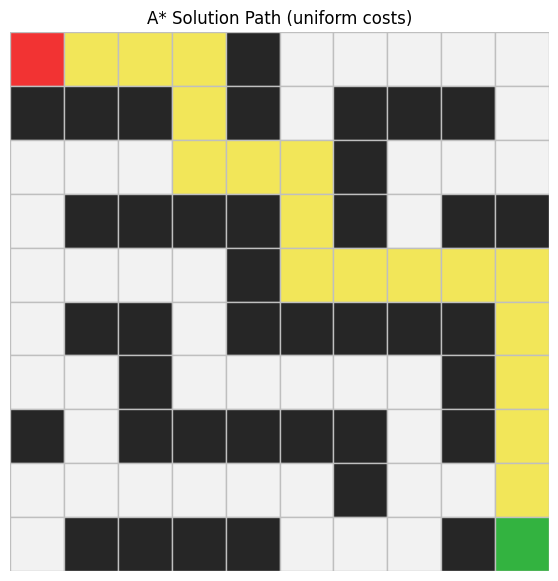

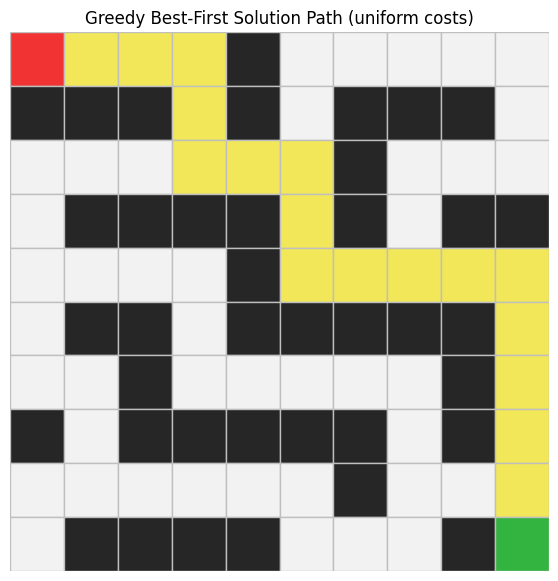

In [23]:
plot_path(
    sample_grid,
    start,
    goal,
    path=uniform_results[1].path,
    title="A* Solution Path (uniform costs)",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=uniform_results[3].path,
    title="Greedy Best-First Solution Path (uniform costs)",
)

In [24]:
turbulence_grid = [
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
]

turbulence_costs = [
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
]

t_start = (2, 0)
t_goal = (2, 6)

turbulence_problem = WeightedGridProblem(
    turbulence_grid, t_start, t_goal, terrain_costs=turbulence_costs
)

turbulence_results = [
    ucs.search(turbulence_problem),
    astar.search(turbulence_problem),
    wastar2.search(turbulence_problem),
    greedy.search(turbulence_problem),
]

show_results(turbulence_results)
     

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,10,10,26,12,35
1,A*,success,10,10,25,12,34
2,Weighted A* (W=2),success,10,10,13,13,26
3,Greedy,success,6,30,6,13,19


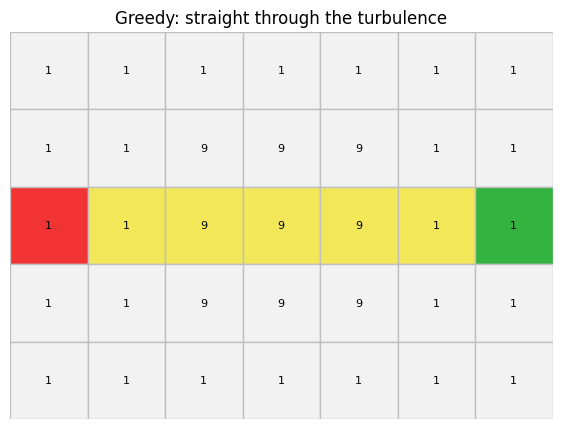

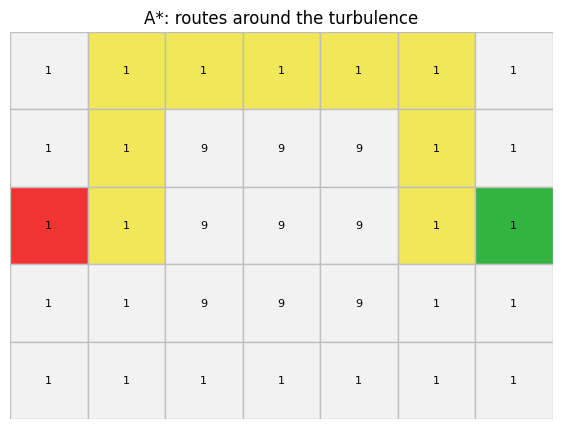

In [25]:
# Greedy vs A* on the turbulence map. The numbers printed in each cell
# are the terrain costs.
plot_path(
    turbulence_grid,
    t_start,
    t_goal,
    path=turbulence_results[3].path,
    terrain_costs=turbulence_costs,
    title="Greedy: straight through the turbulence",
)

plot_path(
    turbulence_grid,
    t_start,
    t_goal,
    path=turbulence_results[1].path,
    terrain_costs=turbulence_costs,
    title="A*: routes around the turbulence",
)

In [26]:
def inflated_heuristic(factor: float):
    
    def h(state, goal):
        return factor * manhattan_distance(state, goal)
    
    return h
    


mild_grid = [
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
]

mild_costs = [
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
]

mild_problem = WeightedGridProblem(
    mild_grid, (2, 0), (2, 6), terrain_costs=mild_costs
)

astar_honest = AStarSearch(manhattan_distance)
astar_inflated = AStarSearch(inflated_heuristic(3.0))

experiment_results = [
    astar_honest.search(uniform_problem),
    astar_inflated.search(uniform_problem),
    astar_honest.search(mild_problem),
    astar_inflated.search(mild_problem),
]

# Relabel rows so the table is readable.
experiment_results[0].algorithm = "A* admissible (uniform map)"
experiment_results[1].algorithm = "A* inflated x3 (uniform map)"
experiment_results[2].algorithm = "A* admissible (mild turbulence)"
experiment_results[3].algorithm = "A* inflated x3 (mild turbulence)"

show_results(experiment_results)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,A* admissible (uniform map),success,18,18,18,5,23
1,A* inflated x3 (uniform map),success,18,18,18,5,23
2,A* admissible (mild turbulence),success,10,10,29,10,35
3,A* inflated x3 (mild turbulence),success,6,12,6,13,19


Custom map 1


In [27]:
custom_grid_1 = [
    [0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0],
]

custom_costs_1 = [
    [1,1,1,1,1,1,1],
    [1,1,5,5,5,1,1],
    [1,1,5,5,5,1,1],
    [1,1,5,5,5,1,1],
    [1,1,1,1,1,1,1],
]

custom_start_1 = (2,0)
custom_goal_1 = (2,6)

In [28]:
custom_problem_1 = WeightedGridProblem(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    terrain_costs=custom_costs_1
)

custom_results_1 = [
    ucs.search(custom_problem_1),
    astar.search(custom_problem_1),
    wastar2.search(custom_problem_1),
    greedy.search(custom_problem_1),
]

show_results(custom_results_1)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,10,10,30,10,35
1,A*,success,10,10,26,12,35
2,Weighted A* (W=2),success,10,10,14,13,27
3,Greedy,success,6,18,6,13,19


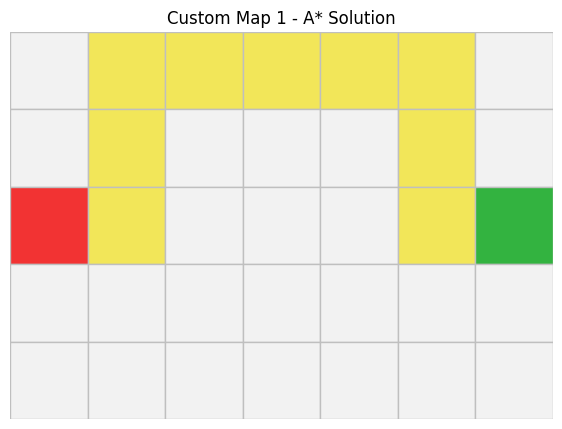

In [29]:
plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=custom_results_1[1].path,
    title="Custom Map 1 - A* Solution"
)

In [30]:
custom_grid_2 = [
    [0,0,0,1,0,0,0],
    [0,1,0,1,0,1,0],
    [0,1,0,1,0,1,0],
    [0,1,0,0,0,1,0],
    [0,1,1,1,0,1,0],
    [0,0,0,0,0,1,0],
    [0,1,1,1,1,1,0],
]

custom_costs_2 = [
    [1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1],
]

custom_start_2 = (0,0)
custom_goal_2 = (6,6)

In [31]:
custom_problem_2 = WeightedGridProblem(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    terrain_costs=custom_costs_2
)

custom_results_2 = [
    ucs.search(custom_problem_2),
    astar.search(custom_problem_2),
    wastar2.search(custom_problem_2),
    greedy.search(custom_problem_2),
]

show_results(custom_results_2)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,18,18,29,3,30
1,A*,success,18,18,29,3,30
2,Weighted A* (W=2),success,18,18,33,4,30
3,Greedy,success,22,22,25,3,28


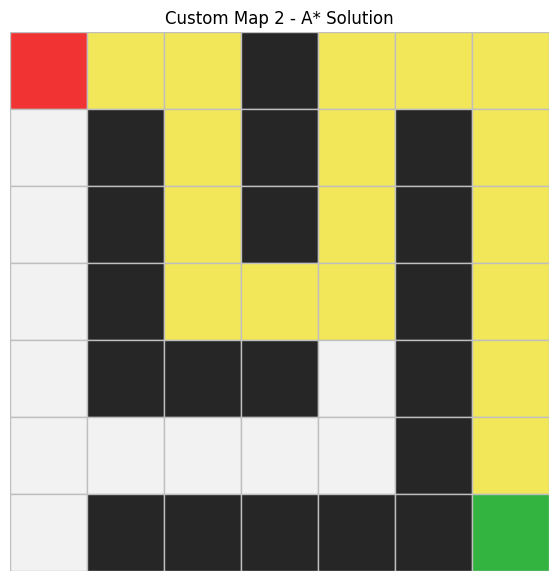

In [32]:
plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=custom_results_2[1].path,
    title="Custom Map 2 - A* Solution"
)

16.1 Heuristic Functions

1. In your own words, what does h(n) estimate, and where does its "knowledge" come from in this lab?

h(n) estimates the remaining cost from the current state to the goal. In this lab, its knowledge comes from the coordinates of the current position and the goal position, using Manhattan or Euclidean distance.

2. Manhattan distance is the exact solution cost of a relaxed problem. Which restrictions of the original drone problem does that relaxation remove?

The relaxation ignores obstacles, terrain costs, and other constraints. It assumes the drone can move directly toward the goal without any barriers.

3. Both Manhattan and Euclidean distance are admissible on our grid. Which one dominates the other, and what does domination predict about nodes expanded?

Manhattan distance dominates Euclidean distance because it usually gives a larger estimate while still remaining admissible. A dominating heuristic generally causes A* to expand fewer nodes.

4. Why does requiring all terrain costs to be ≥ 1 keep Manhattan distance admissible on the weighted maps? What could go wrong with a terrain cost of 0.5?

If every move costs at least 1, then the true path cost can never be lower than the Manhattan distance. If some terrain costs were 0.5, the actual path cost could become smaller than the Manhattan estimate, causing the heuristic to overestimate and lose admissibility.

16.2 Greedy Best-First Search

1. Which quantity does Greedy ignore, and how did the turbulence map punish it for that?

Greedy ignores the path cost g(n). On the turbulence map, it was attracted toward the goal and moved through expensive terrain instead of taking a cheaper route.

2. Greedy expanded fewer nodes than A on some maps. Why is that not enough to call it the better algorithm?*

Expanding fewer nodes only means it searched faster. It does not guarantee the best solution, while A* can still find the optimal path.

3. Describe a drone mission where Greedy's behaviour would actually be acceptable.

Greedy would be acceptable in an emergency situation where the drone must reach a target as quickly as possible and finding the perfect route is less important.

16.3 A* Search

1. Explain f(n) = g(n) + h(n) as a sentence about the drone's flight plan.

A* chooses routes by considering both the cost already spent travelling and the estimated cost remaining to reach the goal.

2. Why must A apply the goal test when a node is popped rather than when it is generated? What could go wrong with an early goal test on the turbulence map?*

A generated goal node may not have the lowest path cost. Testing when the node is popped ensures that the cheapest path to the goal has been found. An early goal test could return a more expensive route.

3. Why does reached need to be a dictionary (state → best node) in this lab, when a plain set was enough for BFS in Part A?

Different paths can reach the same state with different costs. The dictionary allows the algorithm to keep the cheapest version of each state.

4. Compare the nodes expanded by UCS and A on the sample map. What does this gap tell you about the value of the heuristic?*

A* expanded fewer nodes because the heuristic guided the search toward the goal. This shows that a good heuristic improves efficiency.

16.4 Admissibility and Consistency

1. State the definitions of admissible and consistent. Which implies which?

An admissible heuristic never overestimates the true cost to the goal. A consistent heuristic satisfies the triangle inequality between neighboring states. Consistency implies admissibility.

2. What did your inadmissible-heuristic experiment show about the lecture's optimality claim?

The experiment showed that when a heuristic overestimates, A* may lose its guarantee of finding the optimal path.

3. Is Manhattan distance consistent on our unit-cost grid? Check the triangle inequality h(n) ≤ c(n,a,n') + h(n') for a single move and explain.

Yes. A single move changes the Manhattan distance by at most one unit, while the move cost is 1. Therefore the inequality always holds.

16.5 Weighted A* and Trade-offs

1. How does the weight W interpolate between UCS, A, and Greedy?*

When W = 0, Weighted A* behaves like UCS. When W = 1, it becomes standard A*. As W increases, it behaves more like Greedy Best-First Search.

2. What suboptimality bound does Weighted A guarantee, and did your experiments stay well inside that bound?*

Weighted A* guarantees a solution cost no worse than W times the optimal cost. In my experiments, the solutions remained well within that bound.

3. The drone has 90 seconds of battery margin and the flight computer is slow. Which algorithm and which W would you choose, and why?

I would choose Weighted A* with W = 2 because it reduces search effort while still producing solutions that are close to optimal.

16.6 Memory and Real-World Drone Context

1. Which data structures make A memory-hungry? How does IDA (bonus) avoid this, and what does it pay instead?**

A* stores many nodes in the frontier and reached dictionary, which consumes memory. IDA* avoids this by using depth-first search and iterative cost limits, but it performs repeated searches and expands more nodes.

2. In a real drone application, what information would you fold into the terrain costs that this lab leaves out?

I would include weather conditions, wind speed, battery usage, no-fly zones, obstacle density, air traffic, and safety risks.

3. Our heuristic assumes the goal never moves. What breaks if the drone is tracking a moving target, and which lecture concepts become relevant?

The heuristic may become inaccurate because the goal location changes over time. Real-time search, dynamic replanning, and learned heuristics become important.

4. Which single algorithm from Parts A and B combined would you ship on the drone, and under what conditions would you reconsider?

I would choose A* because it balances efficiency and optimality. I would reconsider if memory becomes limited or if decisions must be made extremely quickly, in which case Weighted A* or IDA* may be more suitable.